# K-Means Clustering for Tourist Attractions

## ✨ Enhanced Features:
- 🗺️ Function to test with any K value and visualize on Goa map
- 📊 Function to take coordinates list and K as input and display clusters
- 🎨 Interactive map visualization using Folium
- **💾 NEW: Save/Load clusters for use in other algorithms (e.g., Genetic Algorithm)**

## 🚀 Quick Start:
```python
# Cluster locations into days
result = cluster_tourist_attractions(coordinates, num_days=3)

# Auto-save clusters
result = cluster_tourist_attractions(coordinates, num_days=3, auto_save_clusters=True)

# Load clusters later
loaded = load_clusters('clusters_output.json')

# Get locations for specific day (for GA)
day1 = get_day_locations(loaded, day_number=1)
```

In [2]:
# Import required libraries
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import folium
from folium.plugins import MarkerCluster
import pandas as pd
import json
from datetime import datetime
import os

print('Libraries loaded!')

Libraries loaded!


## 💾 Cluster Persistence Functions

Save and load cluster results for use in other algorithms (e.g., Genetic Algorithm for route optimization).

In [3]:
def save_clusters(result_dict, filename="clusters_output.json", trip_metadata=None):
    """
    Save clustering results to JSON file for use in other algorithms.
    
    Args:
        result_dict: Dictionary returned by cluster_tourist_attractions()
        filename: Output JSON filename
        trip_metadata: Optional dict with trip info (e.g., {'trip_name': '3-day Goa', 'user_id': 'user123'})
    
    Returns:
        str: Path to saved file
    
    Saved Format:
        {
          "trip_id": "unique_id",
          "metadata": {"num_days": 3, "num_locations": 10, ...},
          "clusters": {"1": [0, 3, 5], "2": [1, 4], "3": [2, 6, 7, 8, 9]},
          "centroids": [[lat1, lon1], [lat2, lon2], ...],
          "coordinates": [[lat1, lon1], [lat2, lon2], ...],
          "labels": [0, 1, 2, 0, 1, ...],
          "timestamp": "2024-01-15T10:30:00"
        }
    """
    # Generate unique trip ID
    trip_id = f"trip_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
    
    # Prepare data for JSON serialization
    data = {
        "trip_id": trip_id,
        "metadata": {
            "num_days": result_dict.get('num_days'),
            "num_locations": result_dict.get('num_locations'),
            "timestamp": datetime.now().isoformat(),
            "saved_from": "kmeans_clustering_notebook"
        },
        "clusters": result_dict.get('clusters', {}),
        "centroids": result_dict.get('centroids').tolist() if isinstance(result_dict.get('centroids'), np.ndarray) else result_dict.get('centroids'),
        "coordinates": result_dict.get('coordinates').tolist() if isinstance(result_dict.get('coordinates'), np.ndarray) else result_dict.get('coordinates'),
        "labels": result_dict.get('labels').tolist() if isinstance(result_dict.get('labels'), np.ndarray) else result_dict.get('labels'),
    }
    
    # Add custom metadata if provided
    if trip_metadata:
        data['metadata'].update(trip_metadata)
    
    # Save to JSON
    with open(filename, 'w') as f:
        json.dump(data, f, indent=2)
    
    print(f"\n✅ Clusters saved successfully!")
    print(f"📁 File: {filename}")
    print(f"🆔 Trip ID: {trip_id}")
    print(f"📊 {data['metadata']['num_days']} days, {data['metadata']['num_locations']} locations")
    
    return os.path.abspath(filename)


def load_clusters(filename="clusters_output.json"):
    """
    Load clustering results from JSON file.
    
    Args:
        filename: JSON filename to load
    
    Returns:
        dict: Clustering results with clusters, centroids, coordinates, labels
    
    Example:
        >>> loaded = load_clusters('my_trip.json')
        >>> print(loaded['clusters'])  # {1: [0, 3, 5], 2: [1, 4], ...}
        >>> print(loaded['metadata'])  # Trip metadata
    """
    if not os.path.exists(filename):
        raise FileNotFoundError(f"Cluster file not found: {filename}")
    
    with open(filename, 'r') as f:
        data = json.load(f)
    
    # Convert lists back to numpy arrays
    data['centroids'] = np.array(data['centroids'])
    data['coordinates'] = np.array(data['coordinates'])
    data['labels'] = np.array(data['labels'])
    
    # Convert cluster keys to integers (JSON converts dict keys to strings)
    data['clusters'] = {int(k): v for k, v in data['clusters'].items()}
    
    print(f"\n✅ Clusters loaded successfully!")
    print(f"📁 File: {filename}")
    print(f"🆔 Trip ID: {data['trip_id']}")
    print(f"📊 {data['metadata']['num_days']} days, {data['metadata']['num_locations']} locations")
    print(f"⏰ Saved: {data['metadata']['timestamp']}")
    
    return data


def get_day_locations(clusters_data, day_number):
    """
    Extract location indices and coordinates for a specific day.
    Useful for passing to Genetic Algorithm for that day's route optimization.
    
    Args:
        clusters_data: Dictionary returned by load_clusters()
        day_number: Day number (1, 2, 3, ...)
    
    Returns:
        dict: {
            'location_indices': [0, 3, 5],
            'coordinates': [[lat1, lon1], [lat2, lon2], ...],
            'centroid': [lat, lon]
        }
    """
    if day_number not in clusters_data['clusters']:
        raise ValueError(f"Day {day_number} not found. Available days: {list(clusters_data['clusters'].keys())}")
    
    location_indices = clusters_data['clusters'][day_number]
    all_coords = clusters_data['coordinates']
    day_coords = [all_coords[i] for i in location_indices]
    centroid = clusters_data['centroids'][day_number - 1]  # 0-indexed
    
    return {
        'location_indices': location_indices,
        'coordinates': day_coords,
        'centroid': centroid,
        'num_locations': len(location_indices)
    }


print('💾 Cluster persistence functions loaded!')
print('   - save_clusters(result, filename)')
print('   - load_clusters(filename)')
print('   - get_day_locations(clusters_data, day_number)')

💾 Cluster persistence functions loaded!
   - save_clusters(result, filename)
   - load_clusters(filename)
   - get_day_locations(clusters_data, day_number)


## Sample Coordinates (Goa Tourist Attractions)

In [6]:
# Example coordinates (latitude, longitude) - REPLACE WITH YOUR DATA
coordinates = np.array([
    [15.4922519, 73.7737462],   # Fort Aguada
    [15.3144375, 74.3143073],   # Dudhsagar Falls
    [15.3544232, 73.8838637],   # Velsao Beach
    [15.0887849, 73.9215933],   # Cabo de Rama Fort
    [15.5507728, 74.0264703],   # Harvalem Waterfalls
    [15.6046375, 73.7369631],   # Chapora Fort
    [15.4964204, 73.8091839],   # Reis Magos Fort
    [15.5008429, 73.9114097],   # Basilica of Bom Jesus
    [15.3823119, 73.9288010],   # Kesarval Spring
    [15.5035996, 73.9122204],   # Se Cathedral
])

# Location names for better visualization
location_names = [
    'Fort Aguada',
    'Dudhsagar Falls',
    'Velsao Beach',
    'Cabo de Rama Fort',
    'Harvalem Waterfalls',
    'Chapora Fort',
    'Reis Magos Fort',
    'Basilica of Bom Jesus',
    'Kesarval Spring',
    'Se Cathedral'
]

print(f'Number of locations: {len(coordinates)}')
print(f'\nCoordinates shape: {coordinates.shape}')

Number of locations: 10

Coordinates shape: (10, 2)


## Function 1: Test with Any K and Visualize on Goa Map

This function allows you to test different K values and see the clusters on an interactive map.

In [4]:
def visualize_clusters_on_map(coords, k, location_names=None, map_title="K-Means Clustering"):
    """
    Perform K-Means clustering and visualize results on an interactive Goa map.
    
    Args:
        coords: numpy array of shape (n, 2) with [latitude, longitude]
        k: number of clusters (days)
        location_names: optional list of location names
        map_title: title for the map
    
    Returns:
        labels: array of cluster labels for each coordinate
        centers: cluster centroids
        map_obj: folium map object
    """
    # Perform K-Means clustering
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(coords)
    centers = kmeans.cluster_centers_
    
    # Calculate map center (mean of all coordinates)
    map_center = [coords[:, 0].mean(), coords[:, 1].mean()]
    
    # Create a Folium map centered on Goa
    m = folium.Map(location=map_center, zoom_start=10, tiles='OpenStreetMap')
    
    # Define colors for clusters
    colors = ['red', 'blue', 'green', 'purple', 'orange', 'darkred', 
              'lightred', 'beige', 'darkblue', 'darkgreen', 'cadetblue', 
              'darkpurple', 'pink', 'lightblue', 'lightgreen', 'gray', 
              'black', 'lightgray']
    
    # Add markers for each location
    for i, (lat, lon) in enumerate(coords):
        cluster_id = labels[i]
        color = colors[cluster_id % len(colors)]
        
        # Create popup text
        if location_names and i < len(location_names):
            popup_text = f"<b>{location_names[i]}</b><br>Cluster: {cluster_id}<br>Lat: {lat:.6f}<br>Lon: {lon:.6f}"
        else:
            popup_text = f"Location {i}<br>Cluster: {cluster_id}<br>Lat: {lat:.6f}<br>Lon: {lon:.6f}"
        
        # Add marker
        folium.Marker(
            location=[lat, lon],
            popup=folium.Popup(popup_text, max_width=200),
            icon=folium.Icon(color=color, icon='info-sign'),
            tooltip=f"Cluster {cluster_id}"
        ).add_to(m)
    
    # Add cluster centroids
    for i, (lat, lon) in enumerate(centers):
        color = colors[i % len(colors)]
        folium.Marker(
            location=[lat, lon],
            popup=f"Centroid {i}<br>Lat: {lat:.6f}<br>Lon: {lon:.6f}",
            icon=folium.Icon(color=color, icon='star'),
            tooltip=f"Centroid {i}"
        ).add_to(m)
    
    # Add title
    title_html = f'''
    <div style="position: fixed; top: 10px; left: 50%; transform: translateX(-50%); 
                z-index: 1000; background-color: white; padding: 10px; 
                border: 2px solid grey; border-radius: 5px;">
        <h3 style="margin: 0;">{map_title} (K={k})</h3>
    </div>
    '''
    m.get_root().html.add_child(folium.Element(title_html))
    
    # Print cluster information
    print(f"\n{'='*60}")
    print(f"K-Means Clustering Results (K={k})")
    print(f"{'='*60}")
    
    for i in range(k):
        cluster_indices = np.where(labels == i)[0]
        print(f"\n--- Cluster {i} (Day {i+1}) ---")
        print(f"Number of locations: {len(cluster_indices)}")
        print(f"Centroid: ({centers[i][0]:.6f}, {centers[i][1]:.6f})")
        print("Locations:")
        for idx in cluster_indices:
            if location_names and idx < len(location_names):
                print(f"  - {location_names[idx]}: ({coords[idx][0]:.6f}, {coords[idx][1]:.6f})")
            else:
                print(f"  - Location {idx}: ({coords[idx][0]:.6f}, {coords[idx][1]:.6f})")
    
    return labels, centers, m

### Test with Different K Values

In [7]:
# Test with K=3
labels_k3, centers_k3, map_k3 = visualize_clusters_on_map(
    coordinates, k=3, location_names=location_names, map_title="Goa Tourist Attractions"
)

# Display the map
map_k3


K-Means Clustering Results (K=3)

--- Cluster 0 (Day 1) ---
Number of locations: 1
Centroid: (15.088785, 73.921593)
Locations:
  - Cabo de Rama Fort: (15.088785, 73.921593)

--- Cluster 1 (Day 2) ---
Number of locations: 8
Centroid: (15.485658, 73.872832)
Locations:
  - Fort Aguada: (15.492252, 73.773746)
  - Velsao Beach: (15.354423, 73.883864)
  - Harvalem Waterfalls: (15.550773, 74.026470)
  - Chapora Fort: (15.604638, 73.736963)
  - Reis Magos Fort: (15.496420, 73.809184)
  - Basilica of Bom Jesus: (15.500843, 73.911410)
  - Kesarval Spring: (15.382312, 73.928801)
  - Se Cathedral: (15.503600, 73.912220)

--- Cluster 2 (Day 3) ---
Number of locations: 1
Centroid: (15.314438, 74.314307)
Locations:
  - Dudhsagar Falls: (15.314438, 74.314307)


In [8]:
# Test with K=4
labels_k4, centers_k4, map_k4 = visualize_clusters_on_map(
    coordinates, k=4, location_names=location_names, map_title="Goa Tourist Attractions"
)

# Display the map
map_k4


K-Means Clustering Results (K=4)

--- Cluster 0 (Day 1) ---
Number of locations: 1
Centroid: (15.088785, 73.921593)
Locations:
  - Cabo de Rama Fort: (15.088785, 73.921593)

--- Cluster 1 (Day 2) ---
Number of locations: 5
Centroid: (15.458390, 73.932553)
Locations:
  - Velsao Beach: (15.354423, 73.883864)
  - Harvalem Waterfalls: (15.550773, 74.026470)
  - Basilica of Bom Jesus: (15.500843, 73.911410)
  - Kesarval Spring: (15.382312, 73.928801)
  - Se Cathedral: (15.503600, 73.912220)

--- Cluster 2 (Day 3) ---
Number of locations: 1
Centroid: (15.314438, 74.314307)
Locations:
  - Dudhsagar Falls: (15.314438, 74.314307)

--- Cluster 3 (Day 4) ---
Number of locations: 3
Centroid: (15.531103, 73.773298)
Locations:
  - Fort Aguada: (15.492252, 73.773746)
  - Chapora Fort: (15.604638, 73.736963)
  - Reis Magos Fort: (15.496420, 73.809184)


In [9]:
# Test with K=5
labels_k5, centers_k5, map_k5 = visualize_clusters_on_map(
    coordinates, k=5, location_names=location_names, map_title="Goa Tourist Attractions"
)

# Display the map
map_k5


K-Means Clustering Results (K=5)

--- Cluster 0 (Day 1) ---
Number of locations: 1
Centroid: (15.088785, 73.921593)
Locations:
  - Cabo de Rama Fort: (15.088785, 73.921593)

--- Cluster 1 (Day 2) ---
Number of locations: 3
Centroid: (15.518405, 73.950033)
Locations:
  - Harvalem Waterfalls: (15.550773, 74.026470)
  - Basilica of Bom Jesus: (15.500843, 73.911410)
  - Se Cathedral: (15.503600, 73.912220)

--- Cluster 2 (Day 3) ---
Number of locations: 1
Centroid: (15.314438, 74.314307)
Locations:
  - Dudhsagar Falls: (15.314438, 74.314307)

--- Cluster 3 (Day 4) ---
Number of locations: 3
Centroid: (15.531103, 73.773298)
Locations:
  - Fort Aguada: (15.492252, 73.773746)
  - Chapora Fort: (15.604638, 73.736963)
  - Reis Magos Fort: (15.496420, 73.809184)

--- Cluster 4 (Day 5) ---
Number of locations: 2
Centroid: (15.368368, 73.906332)
Locations:
  - Velsao Beach: (15.354423, 73.883864)
  - Kesarval Spring: (15.382312, 73.928801)


## Function 2: Cluster Any Coordinates List

This function takes any list of coordinates and K as input and displays the clusters.

In [10]:
def cluster_and_display(coords_list, k, names=None, save_html=False, filename="clusters_map.html"):
    """
    Cluster a list of coordinates and display results on map and console.
    
    Args:
        coords_list: list of [lat, lon] coordinates or numpy array
        k: number of clusters
        names: optional list of location names
        save_html: if True, save map to HTML file
        filename: name of HTML file to save
    
    Returns:
        dict: Dictionary containing labels, centers, and map object
    """
    # Convert to numpy array if needed
    if not isinstance(coords_list, np.ndarray):
        coords = np.array(coords_list)
    else:
        coords = coords_list
    
    # Validate input
    if coords.shape[1] != 2:
        raise ValueError("Coordinates must have shape (n, 2) with [latitude, longitude]")
    
    if k < 1:
        raise ValueError("K must be at least 1")
    
    if k > len(coords):
        raise ValueError(f"K ({k}) cannot be greater than number of coordinates ({len(coords)})")
    
    # Perform clustering
    labels, centers, map_obj = visualize_clusters_on_map(
        coords, k, location_names=names, map_title="Custom Coordinates Clustering"
    )
    
    # Save to HTML if requested
    if save_html:
        map_obj.save(filename)
        print(f"\nMap saved to: {filename}")
    
    return {
        'labels': labels,
        'centers': centers,
        'map': map_obj,
        'coordinates': coords
    }

### Example: Using Custom Coordinates

In [11]:
# Example 1: Custom coordinates list
custom_coords = [
    [15.4922519, 73.7737462],   # Fort Aguada
    [15.3144375, 74.3143073],   # Dudhsagar Falls
    [15.3544232, 73.8838637],   # Velsao Beach
    [15.0887849, 73.9215933],   # Cabo de Rama Fort
    [15.5507728, 74.0264703],   # Harvalem Waterfalls
]

custom_names = [
    'Fort Aguada',
    'Dudhsagar Falls',
    'Velsao Beach',
    'Cabo de Rama Fort',
    'Harvalem Waterfalls'
]

# Cluster into 2 groups
result = cluster_and_display(custom_coords, k=2, names=custom_names)

# Display the map
result['map']


K-Means Clustering Results (K=2)

--- Cluster 0 (Day 1) ---
Number of locations: 2
Centroid: (15.201611, 74.117950)
Locations:
  - Dudhsagar Falls: (15.314438, 74.314307)
  - Cabo de Rama Fort: (15.088785, 73.921593)

--- Cluster 1 (Day 2) ---
Number of locations: 3
Centroid: (15.465816, 73.894693)
Locations:
  - Fort Aguada: (15.492252, 73.773746)
  - Velsao Beach: (15.354423, 73.883864)
  - Harvalem Waterfalls: (15.550773, 74.026470)


In [ ]:
# Example 2: Save map to HTML file
result_saved = cluster_and_display(
    custom_coords, 
    k=2, 
    names=custom_names,
    save_html=True,
    filename="custom_clusters_map.html"
)

## Additional: Elbow Method to Find Optimal K

In [ ]:
def find_optimal_k(coords, max_k=10):
    """
    Use the Elbow Method to find optimal number of clusters.
    
    Args:
        coords: numpy array of shape (n, 2) with [latitude, longitude]
        max_k: maximum K to test
    
    Returns:
        inertias: list of inertia values for each K
    """
    inertias = []
    K_range = range(1, min(max_k + 1, len(coords) + 1))
    
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(coords)
        inertias.append(kmeans.inertia_)
    
    # Plot the elbow curve
    plt.figure(figsize=(10, 6))
    plt.plot(K_range, inertias, 'bo-')
    plt.xlabel('Number of Clusters (K)')
    plt.ylabel('Inertia (Within-cluster sum of squares)')
    plt.title('Elbow Method for Optimal K')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return list(inertias)

# Find optimal K for our coordinates
inertias = find_optimal_k(coordinates, max_k=8)

## Visualization: Compare Different K Values

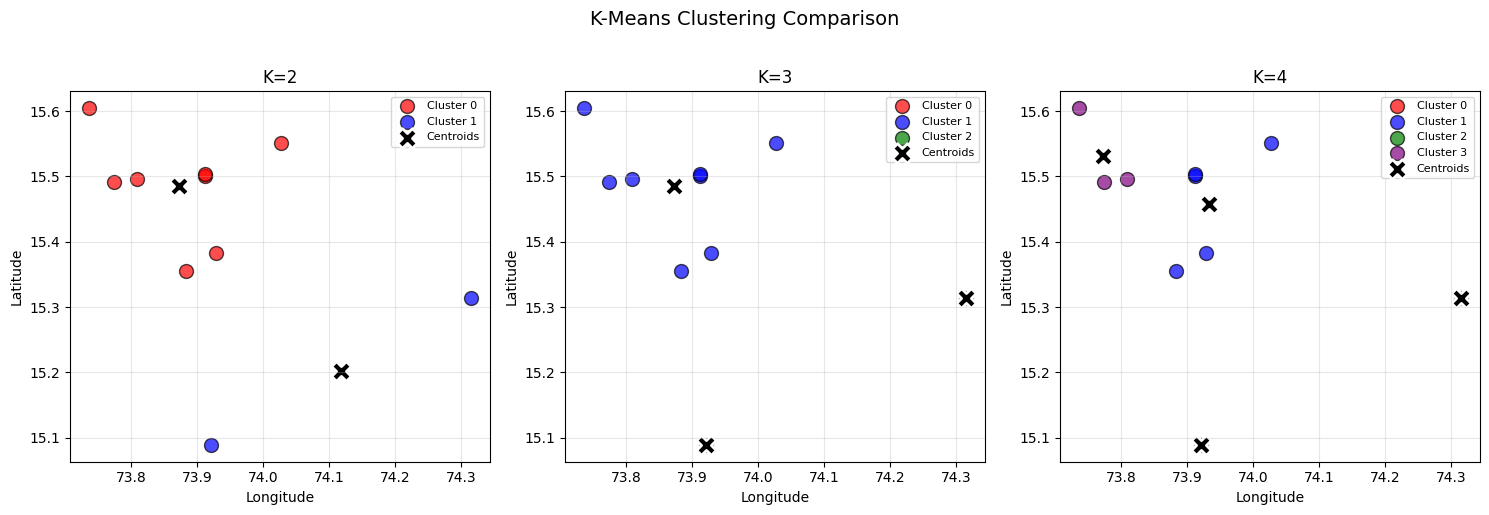

In [12]:
def compare_k_values(coords, k_values, location_names=None):
    """
    Compare clustering results for different K values side by side.
    
    Args:
        coords: numpy array of shape (n, 2) with [latitude, longitude]
        k_values: list of K values to compare
        location_names: optional list of location names
    """
    n_plots = len(k_values)
    fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 5))
    
    if n_plots == 1:
        axes = [axes]
    
    colors = ['red', 'blue', 'green', 'purple', 'orange', 'brown', 'pink', 'gray']
    
    for idx, k in enumerate(k_values):
        ax = axes[idx]
        
        # Perform clustering
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(coords)
        centers = kmeans.cluster_centers_
        
        # Plot clusters
        for i in range(k):
            cluster_points = coords[labels == i]
            ax.scatter(cluster_points[:, 1], cluster_points[:, 0], 
                      c=colors[i % len(colors)], label=f'Cluster {i}', 
                      s=100, edgecolors='black', alpha=0.7)
        
        # Plot centroids
        ax.scatter(centers[:, 1], centers[:, 0],
                  c='black', marker='X', s=200, label='Centroids', 
                  edgecolors='white', linewidth=2)
        
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
        ax.set_title(f'K={k}')
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True, alpha=0.3)
    
    plt.suptitle('K-Means Clustering Comparison', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

# Compare K=2, K=3, K=4
compare_k_values(coordinates, k_values=[2, 3, 4], location_names=location_names)

## Summary Statistics

In [23]:
def print_cluster_summary(coords, k, location_names=None):
    """
    Print detailed summary of clustering results.
    
    Args:
        coords: numpy array of shape (n, 2) with [latitude, longitude]
        k: number of clusters
        location_names: optional list of location names
    """
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(coords)
    centers = kmeans.cluster_centers_
    
    print(f"\n{'='*70}")
    print(f"CLUSTERING SUMMARY (K={k})")
    print(f"{'='*70}")
    print(f"Total locations: {len(coords)}")
    print(f"Number of clusters: {k}")
    print(f"\nCluster Distribution:")
    print(f"{'-'*70}")
    
    for i in range(k):
        cluster_indices = np.where(labels == i)[0]
        cluster_coords = coords[labels == i]
        
        # Calculate cluster statistics
        lat_range = (cluster_coords[:, 0].min(), cluster_coords[:, 0].max())
        lon_range = (cluster_coords[:, 1].min(), cluster_coords[:, 1].max())
        
        print(f"\nCluster {i}:")
        print(f"  Count: {len(cluster_indices)} locations")
        print(f"  Centroid: ({centers[i][0]:.6f}, {centers[i][1]:.6f})")
        print(f"  Latitude range: {lat_range[0]:.6f} to {lat_range[1]:.6f}")
        print(f"  Longitude range: {lon_range[0]:.6f} to {lon_range[1]:.6f}")
        print(f"  Locations:")
        
        for idx in cluster_indices:
            if location_names and idx < len(location_names):
                print(f"    - {location_names[idx]}")
            else:
                print(f"    - Location {idx}")
    
    print(f"\n{'='*70}")

# Print summary for K=3
print_cluster_summary(coordinates, k=3, location_names=location_names)


CLUSTERING SUMMARY (K=3)
Total locations: 10
Number of clusters: 3

Cluster Distribution:
----------------------------------------------------------------------

Cluster 0:
  Count: 1 locations
  Centroid: (15.088785, 73.921593)
  Latitude range: 15.088785 to 15.088785
  Longitude range: 73.921593 to 73.921593
  Locations:
    - Cabo de Rama Fort

Cluster 1:
  Count: 8 locations
  Centroid: (15.485658, 73.872832)
  Latitude range: 15.354423 to 15.604638
  Longitude range: 73.736963 to 74.026470
  Locations:
    - Fort Aguada
    - Velsao Beach
    - Harvalem Waterfalls
    - Chapora Fort
    - Reis Magos Fort
    - Basilica of Bom Jesus
    - Kesarval Spring
    - Se Cathedral

Cluster 2:
  Count: 1 locations
  Centroid: (15.314438, 74.314307)
  Latitude range: 15.314438 to 15.314438
  Longitude range: 74.314307 to 74.314307
  Locations:
    - Dudhsagar Falls



## Interactive: Test Any K Value

In [13]:
# Change this value to test different K values
TEST_K = 3  # <-- Change this to any value you want

# Visualize with the selected K
labels_test, centers_test, map_test = visualize_clusters_on_map(
    coordinates, k=TEST_K, location_names=location_names, map_title="Interactive Test"
)

# Display the map
map_test


K-Means Clustering Results (K=3)

--- Cluster 0 (Day 1) ---
Number of locations: 1
Centroid: (15.088785, 73.921593)
Locations:
  - Cabo de Rama Fort: (15.088785, 73.921593)

--- Cluster 1 (Day 2) ---
Number of locations: 8
Centroid: (15.485658, 73.872832)
Locations:
  - Fort Aguada: (15.492252, 73.773746)
  - Velsao Beach: (15.354423, 73.883864)
  - Harvalem Waterfalls: (15.550773, 74.026470)
  - Chapora Fort: (15.604638, 73.736963)
  - Reis Magos Fort: (15.496420, 73.809184)
  - Basilica of Bom Jesus: (15.500843, 73.911410)
  - Kesarval Spring: (15.382312, 73.928801)
  - Se Cathedral: (15.503600, 73.912220)

--- Cluster 2 (Day 3) ---
Number of locations: 1
Centroid: (15.314438, 74.314307)
Locations:
  - Dudhsagar Falls: (15.314438, 74.314307)


## Save Maps to Files

In [ ]:
# Save all generated maps to HTML files
map_k3.save('goa_clusters_k3.html')
map_k4.save('goa_clusters_k4.html')
map_k5.save('goa_clusters_k5.html')

print("Maps saved:")
print("  - goa_clusters_k3.html")
print("  - goa_clusters_k4.html")
print("  - goa_clusters_k5.html")

---
## 🎯 FINAL FUNCTION: Complete Clustering Solution

This is the main function you should use. It takes coordinates and number of days, performs clustering, and visualizes everything.

In [14]:
def cluster_tourist_attractions(coordinates_list, num_days, location_names=None, 
                                save_map=True, output_filename="tourist_clusters_map.html",
                                auto_save_clusters=False, clusters_filename="clusters_output.json"):
    """Complete K-means clustering solution for tourist route planning.
    
    Takes a list of coordinates and number of days, performs clustering,
    visualizes results on an interactive map, and provides detailed statistics.
    
    Args:
        coordinates_list: List of [latitude, longitude] pairs
                         Example: [[15.49, 73.77], [15.31, 74.31], ...]
        num_days: Number of days for the trip (will be used as K for clustering)
        location_names: Optional list of names for each location
        save_map: If True, saves the map to an HTML file
        output_filename: Name of the HTML file to save
    
    Returns:
        dict: Dictionary containing:
            - 'clusters': Dictionary mapping day number to list of location indices
            - 'labels': Array of cluster labels for each location
            - 'centroids': Array of cluster centroids [lat, lon]
            - 'map': Folium map object (can be displayed in Jupyter)
            - 'coordinates': NumPy array of input coordinates
    
    Example:
        >>> coords = [[15.49, 73.77], [15.31, 74.31], [15.35, 73.88]]
        >>> result = cluster_tourist_attractions(coords, num_days=2)
        >>> result['map']  # Display map in Jupyter
    """
    
    # Convert to numpy array
    coords = np.array(coordinates_list)
    
    # Validate inputs
    if coords.ndim != 2 or coords.shape[1] != 2:
        raise ValueError(f"Coordinates must be a list of [lat, lon] pairs. Got shape: {coords.shape}")
    
    if num_days < 1:
        raise ValueError(f"Number of days must be at least 1. Got: {num_days}")
    
    if num_days > len(coords):
        raise ValueError(f"Number of days ({num_days}) cannot exceed number of locations ({len(coords)})")
    
    num_locations = len(coords)
    
    print("\n" + "="*70)
    print("🗺️  TOURIST ATTRACTIONS CLUSTERING")
    print("="*70)
    print(f"📍 Total Locations: {num_locations}")
    print(f"📅 Number of Days: {num_days}")
    print(f"🎯 Clustering Method: K-Means (K={num_days})")
    print("="*70)
    
    # Perform K-Means clustering
    print("\n⏳ Performing K-Means clustering...")
    kmeans = KMeans(n_clusters=num_days, random_state=42, n_init=10)
    labels = kmeans.fit_predict(coords)
    centroids = kmeans.cluster_centers_
    print("✅ Clustering complete!")
    
    # Create clusters dictionary
    clusters = {}
    for day in range(num_days):
        clusters[day + 1] = np.where(labels == day)[0].tolist()
    
    # Print detailed results
    print("\n" + "="*70)
    print("📊 CLUSTERING RESULTS")
    print("="*70)
    
    for day in range(num_days):
        cluster_indices = clusters[day + 1]
        cluster_coords = coords[labels == day]
        
        print(f"\n📅 Day {day + 1} (Cluster {day})")
        print(f"   {'-'*66}")
        print(f"   Locations to visit: {len(cluster_indices)}")
        print(f"   Centroid: ({centroids[day][0]:.6f}, {centroids[day][1]:.6f})")
        print(f"   ")
        print(f"   Attractions:")
        
        for idx in cluster_indices:
            if location_names and idx < len(location_names):
                name = location_names[idx]
            else:
                name = f"Location {idx + 1}"
            
            lat, lon = coords[idx]
            print(f"      • {name}")
            print(f"        Coordinates: ({lat:.6f}, {lon:.6f})")
    
    print("\n" + "="*70)
    
    # Create interactive map
    print("\n🗺️  Generating interactive map...")
    map_center = [coords[:, 0].mean(), coords[:, 1].mean()]
    m = folium.Map(location=map_center, zoom_start=10, tiles='OpenStreetMap')
    
    # Color scheme for different days
    day_colors = ['red', 'blue', 'green', 'purple', 'orange', 'darkred', 
                  'lightred', 'beige', 'darkblue', 'darkgreen', 'cadetblue', 
                  'darkpurple', 'pink', 'lightblue', 'lightgreen']
    
    # Add markers for each location
    for i, (lat, lon) in enumerate(coords):
        day_num = labels[i] + 1
        color = day_colors[labels[i] % len(day_colors)]
        
        # Create popup content
        if location_names and i < len(location_names):
            location_name = location_names[i]
        else:
            location_name = f"Location {i + 1}"
        
        popup_html = f"""
        <div style="font-family: Arial; width: 200px;">
            <h4 style="margin: 0; color: {color};">{location_name}</h4>
            <hr style="margin: 5px 0;">
            <p style="margin: 5px 0;"><b>Day {day_num}</b></p>
            <p style="margin: 5px 0; font-size: 11px;">
                📍 {lat:.6f}, {lon:.6f}
            </p>
        </div>
        """
        
        # Add marker
        folium.Marker(
            location=[lat, lon],
            popup=folium.Popup(popup_html, max_width=250),
            icon=folium.Icon(color=color, icon='map-marker', prefix='fa'),
            tooltip=f"Day {day_num}: {location_name}"
        ).add_to(m)
    
    # Add centroid markers
    for day in range(num_days):
        lat, lon = centroids[day]
        color = day_colors[day % len(day_colors)]
        
        centroid_html = f"""
        <div style="font-family: Arial;">
            <h4 style="margin: 0;">Day {day + 1} Center</h4>
            <p style="margin: 5px 0; font-size: 11px;">
                📍 {lat:.6f}, {lon:.6f}
            </p>
        </div>
        """
        
        folium.Marker(
            location=[lat, lon],
            popup=folium.Popup(centroid_html, max_width=200),
            icon=folium.Icon(color=color, icon='star', prefix='fa'),
            tooltip=f"Day {day + 1} Centroid"
        ).add_to(m)
    
    # Add legend
    legend_html = f'''
    <div style="position: fixed; 
                top: 10px; left: 50px; width: 250px;
                background-color: white; z-index: 1000;
                border: 2px solid grey; border-radius: 5px;
                padding: 10px; font-family: Arial;">
        <h4 style="margin: 0 0 10px 0;">🗺️ {num_days}-Day Trip Plan</h4>
        <p style="margin: 5px 0; font-size: 12px;">
            📍 Total Locations: {num_locations}<br>
            📅 Days: {num_days}<br>
        </p>
        <hr style="margin: 10px 0;">
        <p style="margin: 0; font-size: 11px;">
            <b>Legend:</b><br>
            📍 Markers = Attractions<br>
            ⭐ Stars = Day Centers
        </p>
    </div>
    '''
    m.get_root().html.add_child(folium.Element(legend_html))
    
    print("✅ Map created successfully!")
    
    # Save map if requested
    if save_map:
        m.save(output_filename)
        print(f"💾 Map saved to: {output_filename}")
    
    # Create matplotlib visualization
    print("\n📊 Creating static visualization...")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Scatter plot of clusters
    for day in range(num_days):
        cluster_points = coords[labels == day]
        color = day_colors[day % len(day_colors)]
        ax1.scatter(cluster_points[:, 1], cluster_points[:, 0], 
                   c=color, label=f'Day {day + 1} ({len(cluster_points)} locations)', 
                   s=150, edgecolors='black', alpha=0.7, linewidth=1.5)
    
    # Plot centroids
    ax1.scatter(centroids[:, 1], centroids[:, 0],
               c='black', marker='*', s=500, label='Day Centers', 
               edgecolors='white', linewidth=2, zorder=5)
    
    ax1.set_xlabel('Longitude', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Latitude', fontsize=12, fontweight='bold')
    ax1.set_title(f'Geographic Clustering: {num_days}-Day Trip', fontsize=14, fontweight='bold')
    ax1.legend(loc='best', fontsize=10)
    ax1.grid(True, alpha=0.3, linestyle='--')
    
    # Plot 2: Bar chart of locations per day
    days = [f'Day {i+1}' for i in range(num_days)]
    counts = [len(clusters[i+1]) for i in range(num_days)]
    colors_bar = [day_colors[i % len(day_colors)] for i in range(num_days)]
    
    bars = ax2.bar(days, counts, color=colors_bar, edgecolor='black', linewidth=1.5, alpha=0.7)
    
    # Add count labels on bars
    for bar, count in zip(bars, counts):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(count)}',
                ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    ax2.set_xlabel('Day', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Number of Locations', fontsize=12, fontweight='bold')
    ax2.set_title('Locations Distribution per Day', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, linestyle='--', axis='y')
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Visualization complete!")
    print("\n" + "="*70)
    print("✨ All done! You can now:")
    print("   1. View the interactive map by displaying result['map']")
    print(f"   2. Open {output_filename} in your browser")
    print("   3. Access cluster details from result['clusters']")
    print("="*70 + "\n")
    
    
    # Auto-save clusters if requested
    if auto_save_clusters:
        save_clusters({
            'clusters': clusters,
            'labels': labels,
            'centroids': centroids,
            'coordinates': coords,
            'num_days': num_days,
            'num_locations': num_locations
        }, filename=clusters_filename)
    
    # Return results
    return {
        'clusters': clusters,
        'labels': labels,
        'centroids': centroids,
        'map': m,
        'coordinates': coords,
        'num_days': num_days,
        'num_locations': num_locations
    }

### 🚀 Usage Example: Plan Your Trip!


🗺️  TOURIST ATTRACTIONS CLUSTERING
📍 Total Locations: 10
📅 Number of Days: 3
🎯 Clustering Method: K-Means (K=3)

⏳ Performing K-Means clustering...
✅ Clustering complete!

📊 CLUSTERING RESULTS

📅 Day 1 (Cluster 0)
   ------------------------------------------------------------------
   Locations to visit: 1
   Centroid: (15.088785, 73.921593)
   
   Attractions:
      • Cabo de Rama Fort
        Coordinates: (15.088785, 73.921593)

📅 Day 2 (Cluster 1)
   ------------------------------------------------------------------
   Locations to visit: 8
   Centroid: (15.485658, 73.872832)
   
   Attractions:
      • Fort Aguada
        Coordinates: (15.492252, 73.773746)
      • Velsao Beach
        Coordinates: (15.354423, 73.883864)
      • Harvalem Waterfalls
        Coordinates: (15.550773, 74.026470)
      • Chapora Fort
        Coordinates: (15.604638, 73.736963)
      • Reis Magos Fort
        Coordinates: (15.496420, 73.809184)
      • Basilica of Bom Jesus
        Coordinates: (15.500

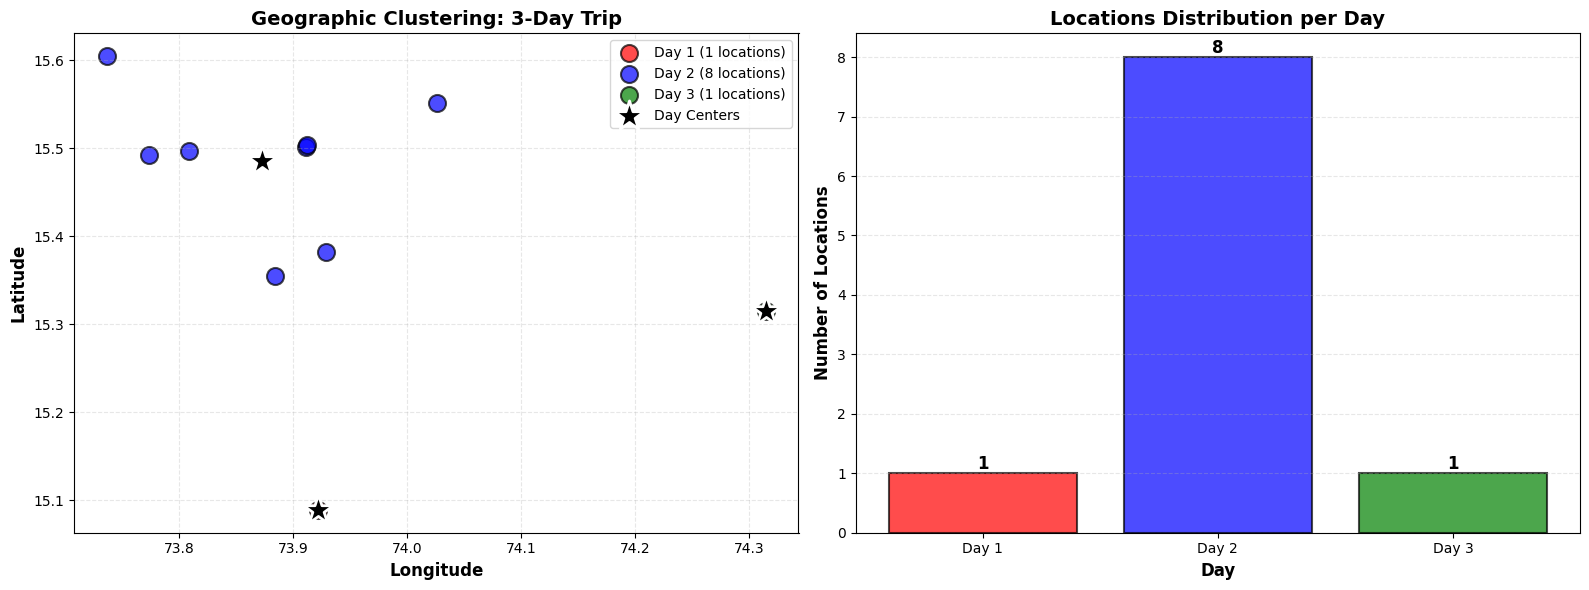

✅ Visualization complete!

✨ All done! You can now:
   1. View the interactive map by displaying result['map']
   2. Open my_3day_goa_trip.html in your browser
   3. Access cluster details from result['clusters']



In [15]:
# Example: Plan a 3-day trip to Goa
my_coordinates = [
    [15.4922519, 73.7737462],   # Fort Aguada
    [15.3144375, 74.3143073],   # Dudhsagar Falls
    [15.3544232, 73.8838637],   # Velsao Beach
    [15.0887849, 73.9215933],   # Cabo de Rama Fort
    [15.5507728, 74.0264703],   # Harvalem Waterfalls
    [15.6046375, 73.7369631],   # Chapora Fort
    [15.4964204, 73.8091839],   # Reis Magos Fort
    [15.5008429, 73.9114097],   # Basilica of Bom Jesus
    [15.3823119, 73.9288010],   # Kesarval Spring
    [15.5035996, 73.9122204],   # Se Cathedral
]

my_location_names = [
    'Fort Aguada',
    'Dudhsagar Falls',
    'Velsao Beach',
    'Cabo de Rama Fort',
    'Harvalem Waterfalls',
    'Chapora Fort',
    'Reis Magos Fort',
    'Basilica of Bom Jesus',
    'Kesarval Spring',
    'Se Cathedral'
]

# Cluster into 3 days
result = cluster_tourist_attractions(
    coordinates_list=my_coordinates,
    num_days=3,
    location_names=my_location_names,
    save_map=True,
    output_filename="my_3day_goa_trip.html"
)

# Display the interactive map
result['map']

### 📋 Access Clustering Results

In [16]:
# Access the clusters
print("\nClusters (Day → Location Indices):")
for day, indices in result['clusters'].items():
    print(f"Day {day}: {indices}")

# Access centroids
print("\nCentroids (Day Centers):")
for i, centroid in enumerate(result['centroids']):
    print(f"Day {i+1}: {centroid}")

# Summary
print(f"\nTotal locations: {result['num_locations']}")
print(f"Number of days: {result['num_days']}")


Clusters (Day → Location Indices):
Day 1: [3]
Day 2: [0, 2, 4, 5, 6, 7, 8, 9]
Day 3: [1]

Centroids (Day Centers):
Day 1: [15.0887849 73.9215933]
Day 2: [15.48565753 73.87283229]
Day 3: [15.3144375 74.3143073]

Total locations: 10
Number of days: 3


### 🎨 Try Different Number of Days


🗺️  TOURIST ATTRACTIONS CLUSTERING
📍 Total Locations: 10
📅 Number of Days: 4
🎯 Clustering Method: K-Means (K=4)

⏳ Performing K-Means clustering...
✅ Clustering complete!

📊 CLUSTERING RESULTS

📅 Day 1 (Cluster 0)
   ------------------------------------------------------------------
   Locations to visit: 1
   Centroid: (15.088785, 73.921593)
   
   Attractions:
      • Cabo de Rama Fort
        Coordinates: (15.088785, 73.921593)

📅 Day 2 (Cluster 1)
   ------------------------------------------------------------------
   Locations to visit: 5
   Centroid: (15.458390, 73.932553)
   
   Attractions:
      • Velsao Beach
        Coordinates: (15.354423, 73.883864)
      • Harvalem Waterfalls
        Coordinates: (15.550773, 74.026470)
      • Basilica of Bom Jesus
        Coordinates: (15.500843, 73.911410)
      • Kesarval Spring
        Coordinates: (15.382312, 73.928801)
      • Se Cathedral
        Coordinates: (15.503600, 73.912220)

📅 Day 3 (Cluster 2)
   ------------------------

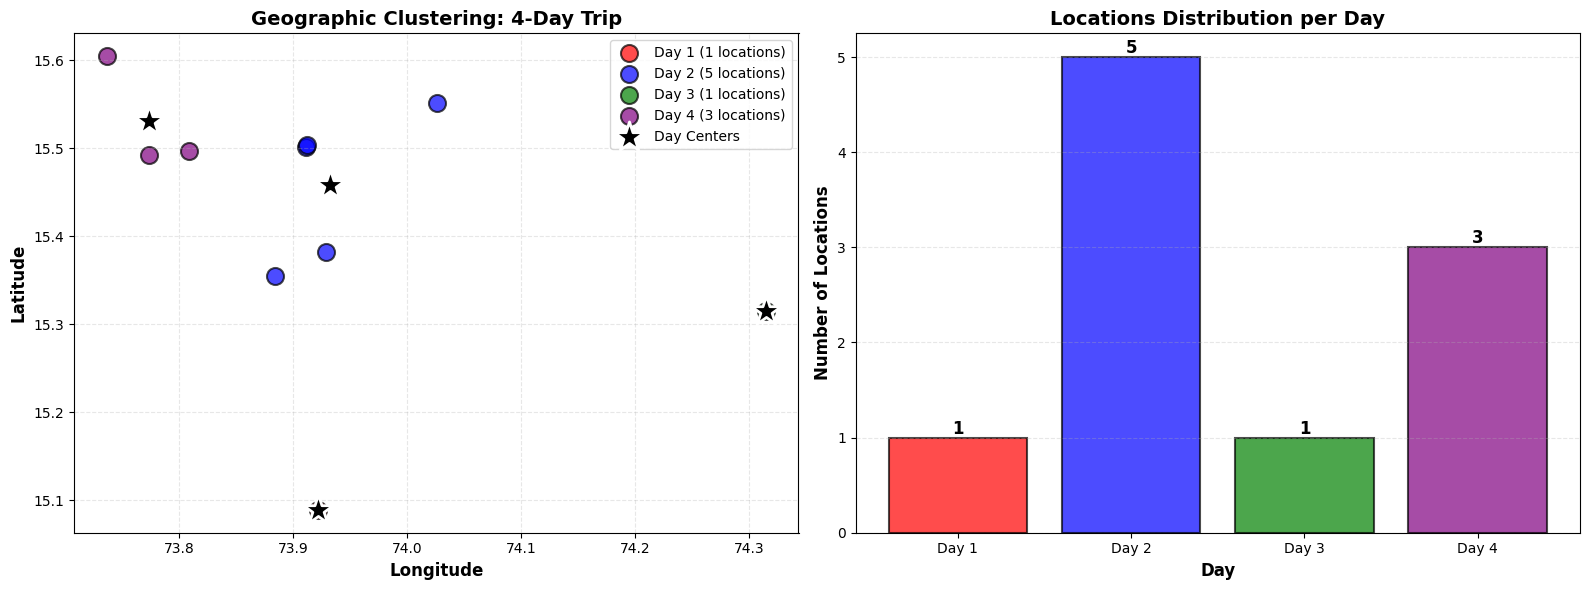

✅ Visualization complete!

✨ All done! You can now:
   1. View the interactive map by displaying result['map']
   2. Open my_4day_goa_trip.html in your browser
   3. Access cluster details from result['clusters']



In [17]:
# Try with 4 days
result_4days = cluster_tourist_attractions(
    coordinates_list=my_coordinates,
    num_days=4,
    location_names=my_location_names,
    output_filename="my_4day_goa_trip.html"
)

result_4days['map']

### 💡 Quick Test with Your Own Coordinates


🗺️  TOURIST ATTRACTIONS CLUSTERING
📍 Total Locations: 15
📅 Number of Days: 2
🎯 Clustering Method: K-Means (K=2)

⏳ Performing K-Means clustering...
✅ Clustering complete!

📊 CLUSTERING RESULTS

📅 Day 1 (Cluster 0)
   ------------------------------------------------------------------
   Locations to visit: 11
   Centroid: (15.499061, 73.840562)
   
   Attractions:
      • Fort Aguada
        Coordinates: (15.492252, 73.773746)
      • Velsao Beach
        Coordinates: (15.354423, 73.883864)
      • Harvalem Waterfalls
        Coordinates: (15.550773, 74.026470)
      • Chapora Fort
        Coordinates: (15.604638, 73.736963)
      • Reis Magos Fort
        Coordinates: (15.496420, 73.809184)
      • Basilica of Bom Jesus
        Coordinates: (15.500843, 73.911410)
      • Kesarval Spring Verna Waterfall
        Coordinates: (15.382312, 73.928801)
      • Se Cathedral
        Coordinates: (15.503600, 73.912220)
      • Candolim Beach
        Coordinates: (15.517975, 73.762612)
      • S

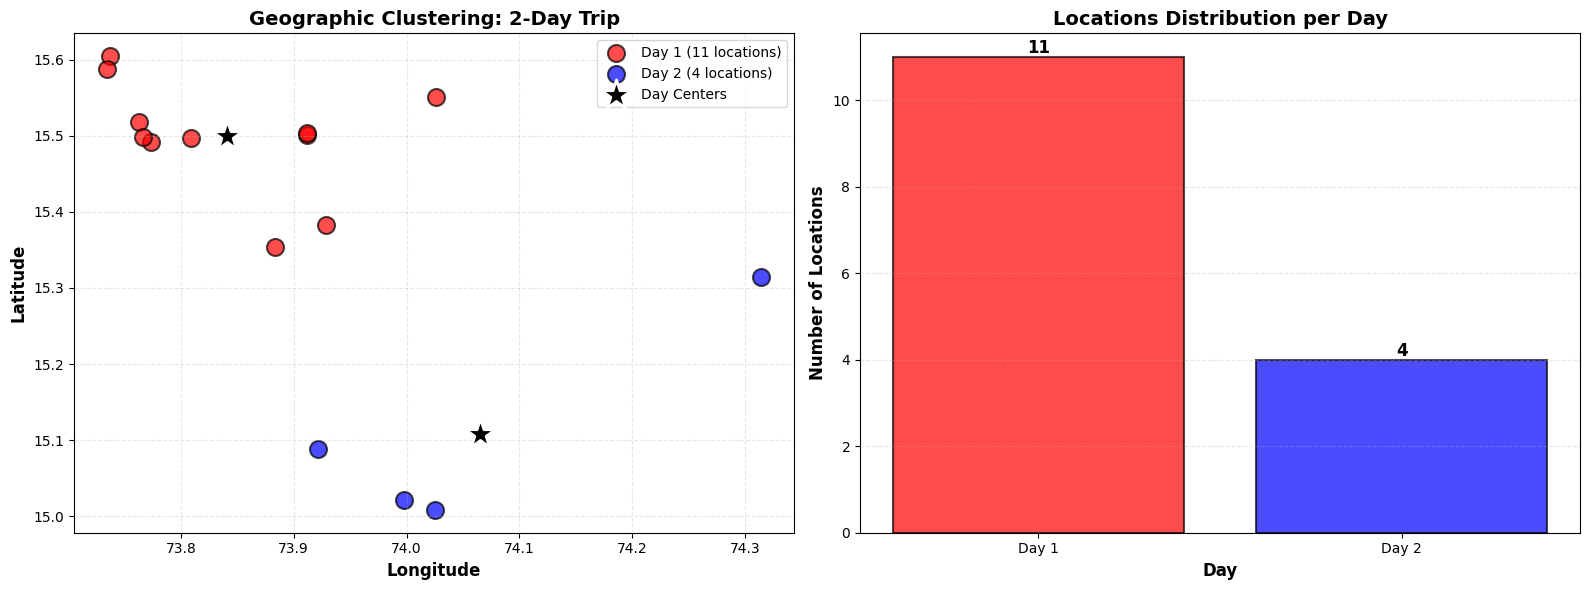

✅ Visualization complete!

✨ All done! You can now:
   1. View the interactive map by displaying result['map']
   2. Open tourist_clusters_map.html in your browser
   3. Access cluster details from result['clusters']



In [19]:
# Replace with your own coordinates and number of days!
YOUR_COORDINATES = [
    [15.4922519, 73.7737462],  # Fort Aguada
    [15.3144375, 74.3143073],  # Dudhsagar Falls
    [15.3544232, 73.8838637],  # Velsao Beach
    [15.0887849, 73.9215933],  # Cabo de Rama Fort
    [15.5507728, 74.0264703],  # Harvalem Waterfalls
    [15.6046375, 73.7369631],  # Chapora Fort
    [15.4964204, 73.8091839],  # Reis Magos Fort
    [15.5008429, 73.9114097],  # Basilica of Bom Jesus
    [15.3823119, 73.9288010],  # Kesarval Spring Verna Waterfall
    [15.5035996, 73.9122204],  # Se Cathedral
    [15.5179749, 73.7626122],  # Candolim Beach
    [15.4984466, 73.7663559],  # Sinquerim Fort
    [15.5879910, 73.7345501],  # Vagator beach Goa india
    [15.0083261, 74.0251467],  # Palolem Beach, GOA
    [15.0218547, 73.9977915],  # Honeymoon beach (Agonda side)
]

YOUR_NAMES = [
    "Fort Aguada",
    "Dudhsagar Falls",
    "Velsao Beach",
    "Cabo de Rama Fort",
    "Harvalem Waterfalls",
    "Chapora Fort",
    "Reis Magos Fort",
    "Basilica of Bom Jesus",
    "Kesarval Spring Verna Waterfall",
    "Se Cathedral",
    "Candolim Beach",
    "Sinquerim Fort",
    "Vagator beach Goa india",
    "Palolem Beach, GOA",
    "Honeymoon beach",
]

YOUR_NUM_DAYS = 2

# Run clustering
result = cluster_tourist_attractions(
    coordinates_list=YOUR_COORDINATES,
    num_days=YOUR_NUM_DAYS,
    location_names=YOUR_NAMES
)
result['map']

---
## 💾 Save & Load Clusters Examples

Save your clustering results to use in other algorithms (e.g., Genetic Algorithm)

In [20]:
# Save the clustering result from above
save_path = save_clusters(
    result,
    filename="my_goa_trip_clusters.json",
    trip_metadata={
        'trip_name': '3-Day Goa Adventure',
        'created_by': 'wanderwise_user',
        'notes': 'First test clustering'
    }
)

print(f"\n📂 Full path: {save_path}")


✅ Clusters saved successfully!
📁 File: my_goa_trip_clusters.json
🆔 Trip ID: trip_20260401_230955
📊 2 days, 15 locations

📂 Full path: /home/maxwell/Desktop/WanderWise/my_goa_trip_clusters.json


In [21]:
# Load clusters back from file
loaded_clusters = load_clusters("my_goa_trip_clusters.json")

# View the structure
print("\n📋 Loaded data structure:")
print(f"  - Trip ID: {loaded_clusters['trip_id']}")
print(f"  - Clusters: {loaded_clusters['clusters']}")
print(f"  - Centroids shape: {loaded_clusters['centroids'].shape}")
print(f"  - Coordinates shape: {loaded_clusters['coordinates'].shape}")


✅ Clusters loaded successfully!
📁 File: my_goa_trip_clusters.json
🆔 Trip ID: trip_20260401_230955
📊 2 days, 15 locations
⏰ Saved: 2026-04-01T23:09:55.391592

📋 Loaded data structure:
  - Trip ID: trip_20260401_230955
  - Clusters: {1: [0, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12], 2: [1, 3, 13, 14]}
  - Centroids shape: (2, 2)
  - Coordinates shape: (15, 2)


### 🎯 Extract Locations for Specific Day (for GA input)

In [22]:
# Get locations for Day 1 (to pass to Genetic Algorithm)
day1_data = get_day_locations(loaded_clusters, day_number=1)

print("\n📅 Day 1 Data for GA:")
print(f"  Location indices: {day1_data['location_indices']}")
print(f"  Number of locations: {day1_data['num_locations']}")
print(f"  Centroid: {day1_data['centroid']}")
print(f"  Coordinates:")
for i, coord in enumerate(day1_data['coordinates']):
    print(f"    {i}: {coord}")


📅 Day 1 Data for GA:
  Location indices: [0, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12]
  Number of locations: 11
  Centroid: [15.49906115 73.8405615 ]
  Coordinates:
    0: [15.4922519 73.7737462]
    1: [15.3544232 73.8838637]
    2: [15.5507728 74.0264703]
    3: [15.6046375 73.7369631]
    4: [15.4964204 73.8091839]
    5: [15.5008429 73.9114097]
    6: [15.3823119 73.928801 ]
    7: [15.5035996 73.9122204]
    8: [15.5179749 73.7626122]
    9: [15.4984466 73.7663559]
    10: [15.587991  73.7345501]


In [23]:
# Example: Get all days for complete trip optimization
print("\n🗺️ Complete Trip Summary:")
print("=" * 60)

for day in loaded_clusters['clusters'].keys():
    day_info = get_day_locations(loaded_clusters, day)
    print(f"\nDay {day}:")
    print(f"  Locations: {day_info['num_locations']}")
    print(f"  Indices: {day_info['location_indices']}")
    print(f"  Ready for GA optimization: ✅")


🗺️ Complete Trip Summary:

Day 1:
  Locations: 11
  Indices: [0, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12]
  Ready for GA optimization: ✅

Day 2:
  Locations: 4
  Indices: [1, 3, 13, 14]
  Ready for GA optimization: ✅


### 📝 Integration with Genetic Algorithm

**How to use these clusters in your GA module:**

```python
# 1. Load clusters
clusters = load_clusters('my_goa_trip_clusters.json')

# 2. For each day, optimize route with GA
optimized_routes = {}
for day in clusters['clusters'].keys():
    day_data = get_day_locations(clusters, day)
    
    # Pass to your GA
    optimized_route = genetic_algorithm(
        coordinates=day_data['coordinates'],
        location_indices=day_data['location_indices'],
        start_location=day_data['centroid']  # Optional: start near centroid
    )
    
    optimized_routes[day] = optimized_route

# 3. You now have optimized route for each day!
```

**JSON Structure Reference:**
```json
{
  "trip_id": "trip_20240315_143022",
  "metadata": {
    "num_days": 3,
    "num_locations": 10,
    "trip_name": "3-Day Goa Adventure"
  },
  "clusters": {
    "1": [0, 3, 5, 7],
    "2": [1, 4, 8],
    "3": [2, 6, 9]
  },
  "centroids": [[15.49, 73.77], [15.31, 74.31], [15.55, 73.91]],
  "coordinates": [[15.49, 73.77], [15.31, 74.31], ...],
  "labels": [0, 1, 2, 0, 1, ...]
}
```